In [1]:
import gymnasium as gym
from tile_coding import TileCoder
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [70]:
env = gym.make("MountainCar-v0", max_episode_steps=2000)

NUM_ACTIONS = 3
state = env.reset()[0]
q_coder = TileCoder(low=[-1.2, -0.07], high=[0.6, 0.07], num_tiles=8, tile_per_dimension=[8, 8], num_actions=NUM_ACTIONS)
s_coder = TileCoder(low=[-1.2, -0.07], high=[0.6, 0.07], num_tiles=8, tile_per_dimension=[8, 8])

In [44]:
def h(state:np.ndarray, action:int, theta:np.ndarray):
    x = q_coder.get_vector(state=state, action=action)
    return theta.T@x


def pi(state:np.ndarray, theta:np.ndarray, action:int=None):
    logits = np.array([h(state, a, theta) for a in range(NUM_ACTIONS)], dtype=np.float64)
    logits = logits - logits.max()
    probs = np.exp(logits)
    probs /= probs.sum()
    if action is None:
        return probs
    return probs[action]


def grad_log_pi(action:int, state:np.ndarray, theta:np.ndarray):
    vectors = np.array([q_coder.get_vector(state, b) for b in range(NUM_ACTIONS)])
    S = np.sum(pi(state, theta)[:, None] * vectors, axis=0)
    return q_coder.get_vector(state, action) - S

In [87]:
def generate_trajectory(env:gym.Env, theta:np.ndarray, truncate:bool=False):
    state = env.reset()[0]
    trajectory = [{'state':state}]

    terminated = False
    truncated = False
    while not (terminated or truncated):
        actions_p = pi(state, theta)
        action = int(np.random.choice(NUM_ACTIONS, p=actions_p))
        next_state, reward, terminated, truncated, _ = env.step(action)
        if not truncate:
            truncated = False

        trajectory[-1]['action'] = action
        trajectory.append({'reward':reward, 'state':next_state})
        state = next_state

    return trajectory

In [88]:
def reinforce(
    env:gym.Env,
    theta:np.ndarray,
    episodes:int,
    alpha:float,
    gamma:float,
    truncate:bool=None
):
    rewards_per_episode = []

    for _ in tqdm(range(episodes), leave=False):
        trajectory = generate_trajectory(env=env, theta=theta, truncate=truncate)
        rewards_per_episode.append(sum(x['reward'] for x in trajectory[1:]))

        for t in range(len(trajectory) - 1):
            G = np.sum([gamma ** i * x['reward'] for i, x in enumerate(trajectory[t+1:])])
            state = trajectory[t]['state']
            action = trajectory[t]['action']
            theta = theta + alpha * gamma**t * G * grad_log_pi(action, state, theta)

    return {
        'theta':theta,
        'rewards_per_episode':rewards_per_episode
    }

In [89]:
def reinforce_with_baseline(
    env:gym.Env,
    theta:np.ndarray,
    w:np.ndarray,
    episodes:int,
    alpha_theta:float,
    alpha_w:float,
    gamma:float,
    truncate:bool=False
):
    rewards_per_episode = []

    pbar = tqdm(range(episodes), leave=False)
    for _ in pbar:
        trajectory = generate_trajectory(env=env, theta=theta, truncate=truncate)
        rewards_per_episode.append(sum(x['reward'] for x in trajectory[1:]))
        pbar.set_postfix({'rewards':rewards_per_episode[-1]})

        for t in range(len(trajectory) - 1):
            G = np.sum([gamma ** i * x['reward'] for i, x in enumerate(trajectory[t+1:])])
            state = trajectory[t]['state']
            action = trajectory[t]['action']

            baseline_state = s_coder.get_vector(state)

            delta = G - w.T@baseline_state
            w = w + alpha_w * delta * baseline_state
            theta = theta + alpha_theta * gamma**t * delta * grad_log_pi(action, state, theta)

    return {
        'theta':theta,
        'w':w,
        'rewards_per_episode':rewards_per_episode
    }

In [90]:
def one_step_actor_critic(
    env:gym.Env,
    theta:np.ndarray,
    w:np.ndarray,
    episodes:int,
    alpha_theta:float,
    alpha_w:float,
    gamma:float
):
    rewards_per_episode = []

    pbar = tqdm(range(episodes), leave=False)
    for _ in pbar:
        state = env.reset()[0]
        terminated = False
        truncated = False
        episode_reward = 0

        I = 1

        while not (terminated or truncated):
            actions_p = pi(state, theta)
            action = np.random.choice(NUM_ACTIONS, p=actions_p)
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode_reward += reward

            x_state = s_coder.get_vector(state)
            x_next_state = s_coder.get_vector(next_state)

            if terminated:
                delta = reward - w.T@x_state
            else:
                delta = reward + gamma * w.T@x_next_state - w.T@x_state

            w = w + alpha_w * delta * x_state
            theta = theta + alpha_theta * I * delta * grad_log_pi(action, state, theta)

            I = gamma * I
            state = next_state

        rewards_per_episode.append(episode_reward)
        pbar.set_postfix({'rewards':rewards_per_episode[-1]})
    
    pbar.close()

    return {
        'theta':theta,
        'w':w,
        'rewards_per_episode':rewards_per_episode
    }

In [94]:
def actor_critic_with_eligibility_traces(
    env:gym.Env,
    theta:np.ndarray,
    w:np.ndarray,
    episodes:int,
    alpha_theta:float,
    alpha_w:float,
    lambda_theta:float,
    lambda_w:float,
    gamma:float
):
    rewards_per_episode = []

    pbar = tqdm(range(episodes), leave=False)
    for _ in pbar:
        state = env.reset()[0]
        episode_rewards = 0
        I = 1

        z_theta = np.zeros_like(theta)
        z_w = np.zeros_like(w)

        terminated, truncated = False, False
        while not(terminated or truncated):
            actions_p = pi(state, theta)
            action = np.random.choice(NUM_ACTIONS, p=actions_p)
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode_rewards += reward

            x_state = s_coder.get_vector(state)
            x_next_state = s_coder.get_vector(next_state)

            if terminated:
                delta = reward - w.T@x_state
            else:
                delta = reward + gamma * w.T@x_next_state - w.T@x_state

            z_w = gamma * lambda_w * z_w + x_state
            z_theta = gamma * lambda_theta * z_theta + I * grad_log_pi(action, state, theta)

            w = w + alpha_w * delta * z_w
            theta = theta + alpha_theta * delta * z_theta

            state = next_state
            I = gamma * I

        rewards_per_episode.append(episode_rewards)
        pbar.set_postfix({'rewards':episode_rewards})

    return {
            'theta':theta,
            'w':w,
            'rewards_per_episode':rewards_per_episode
        }
    

In [96]:
theta = np.zeros(q_coder.num_features)
w = np.zeros(s_coder.num_features)

actor_critic_et_result = actor_critic_with_eligibility_traces(
    env=env,
    theta=theta,
    w=w,
    episodes=1000,
    alpha_theta=0.05/8,
    alpha_w=0.1/8,
    lambda_w=0.8,
    lambda_theta=0.8,
    gamma=0.99,
)

one_step_ac_result = one_step_actor_critic(
    env=env,
    theta=theta,
    w=w,
    episodes=1000,
    alpha_theta=0.05/8,
    alpha_w=0.1/8,
    gamma=0.99
)

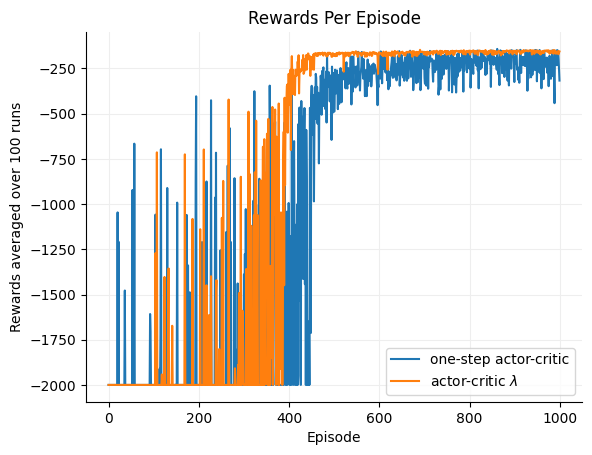

In [97]:
fig = plt.figure()
ax = plt.subplot(111)

ax.plot(one_step_ac_result['rewards_per_episode'], label='one-step actor-critic')
ax.plot(actor_critic_et_result['rewards_per_episode'], label=r'actor-critic $\lambda$')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(c="#eee")
ax.set_xlabel("Episode")
ax.set_ylabel("Rewards averaged over 100 runs")
ax.set_title("Rewards Per Episode");
ax.legend();

In [112]:
ac_et_trajectory = generate_trajectory(env, actor_critic_et_result['theta'])
one_step_ac_trajectory = generate_trajectory(env, one_step_ac_result['theta'])

print("Actor-critic with eligibility traces:", len(ac_et_trajectory), 'steps')
print("One-step Actor-critic:", len(one_step_ac_trajectory), 'steps')

Actor-critic with eligibility traces: 153 steps
One-step Actor-critic: 194 steps


Note that none of the REINFORCE and REINFORCE-with-baseline could be well optimized due to their high variance.